In [ ]:
!mkdir -p /content/configs
!cp /content/defaults_divi.yaml /content/configs/defaults_divi.yaml
%cd /content
!python run_divi_runtime_synth.py --config configs/defaults_divi.yaml

!python run_divi_runtime_real.py --dataset isolet --config configs/defaults_divi.yaml
!python run_divi_runtime_real.py --dataset 20ng --config configs/defaults_divi.yaml

!python run_divi_sensitivity_synth.py --factor beta_mult --values 0.25,0.5,1.0,2.0,4.0 --config configs/defaults_divi.yaml
!python run_divi_sensitivity_synth.py --factor Tsplit --values 10,20,40,80 --config configs/defaults_divi.yaml
!python run_divi_sensitivity_synth.py --factor tau_mult --values 0.9,1.0,1.1,1.2 --config configs/defaults_divi.yaml

!python make_paper_outputs.py --root outputs_revision --outdir outputs_revision/aggregated --make-plots

!python /content/run_divi_runtime_synth.py --config /content/defaults_divi.yaml

/content
modules.json: 100% 349/349 [00:00<00:00, 1.28MB/s]
config_sentence_transformers.json: 100% 116/116 [00:00<00:00, 497kB/s]
README.md: 10.5kB [00:00, 23.1MB/s]
sentence_bert_config.json: 100% 53.0/53.0 [00:00<00:00, 232kB/s]
config.json: 100% 612/612 [00:00<00:00, 2.55MB/s]
model.safetensors: 100% 90.9M/90.9M [00:01<00:00, 78.4MB/s]
Loading weights: 100% 103/103 [00:00<00:00, 2196.46it/s, Materializing param=pooler.dense.weight]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
tokenizer_config.json: 100% 350/350 [00:00<00:00, 1.51MB/s]
vocab.txt: 232kB [00:00, 30.1MB/s]
tokenizer.json: 466kB [00:00, 65.7MB/s]
special_tokens_map.json: 100% 112/112 [00:00<00:00, 439kB/s]
config.json: 100% 190/190 [00:00<00:00, 828kB/s

In [ ]:
import pandas as pd

runtime_real = pd.read_csv("outputs_revision/aggregated/paper_tables/table_runtime_real_main.csv")
sens_beta = pd.read_csv("outputs_revision/aggregated/paper_tables/table_sensitivity_beta_mult_synthetic.csv")
sens_tsplit = pd.read_csv("outputs_revision/aggregated/paper_tables/table_sensitivity_Tsplit_synthetic.csv")
sens_tau = pd.read_csv("outputs_revision/aggregated/paper_tables/table_sensitivity_tau_mult_synthetic.csv")

display(runtime_real)
display(sens_beta)
display(sens_tsplit)
display(sens_tau)

,Dataset,Method,ARI,NMI,ACC,Runtime (s),Final $K$,Selected dims,Splits
0,ISOLET,DIVI-Info,0.460 (0.143),0.585 (0.122),0.593 (0.096),22.26 (1.14),4.0 (0.0),578.0 (1.7),3.0 (0.0)
1,ISOLET,KMeans,0.632 (0.001),0.716 (0.001),0.752 (0.001),0.59 (0.04),5.0 (0.0),--,0.0 (0.0)
2,ISOLET,GMM,0.580 (0.112),0.684 (0.068),0.705 (0.106),2.81 (0.75),5.0 (0.0),--,0.0 (0.0)
3,ISOLET,SPKM,0.551 (0.000),0.640 (0.000),0.722 (0.000),9.26 (0.66),5.0 (0.0),23.0 (0.0),0.0 (0.0)
4,20NG,DIVI-Info,0.759 (0.133),0.753 (0.074),0.876 (0.118),16.49 (1.03),4.0 (0.0),351.6 (1.1),3.0 (0.0)
5,20NG,KMeans,0.845 (0.002),0.803 (0.002),0.939 (0.001),0.40 (0.02),4.0 (0.0),--,0.0 (0.0)
6,20NG,GMM,0.718 (0.167),0.735 (0.088),0.820 (0.160),1.42 (0.15),4.0 (0.0),--,0.0 (0.0)
7,20NG,SPKM,0.514 (0.000),0.515 (0.000),0.775 (0.000),7.98 (0.61),4.0 (0.0),30.0 (0.0),0.0 (0.0)


,Dataset,Sensitivity value,ARI,NMI,Feature F1,Runtime (s),Final $K$,Selected dims,Splits
0,synthetic_n1000_d100_fixedseed3102,0.25,0.876 (0.008),0.908 (0.004),0.519 (0.017),2.46 (0.29),4.0 (0.0),28.6 (1.3),3.0 (0.0)
1,synthetic_n1000_d100_fixedseed3102,0.50,0.877 (0.010),0.909 (0.005),0.828 (0.031),2.59 (0.27),4.0 (0.0),14.2 (0.9),3.0 (0.0)
2,synthetic_n1000_d100_fixedseed3102,1.00,0.879 (0.012),0.909 (0.006),1.000 (0.000),2.53 (0.20),4.0 (0.0),10.0 (0.0),3.0 (0.0)
3,synthetic_n1000_d100_fixedseed3102,2.00,0.880 (0.012),0.910 (0.006),1.000 (0.000),2.51 (0.24),4.0 (0.0),10.0 (0.0),3.0 (0.0)
4,synthetic_n1000_d100_fixedseed3102,4.00,0.880 (0.012),0.910 (0.006),1.000 (0.000),2.53 (0.23),4.0 (0.0),10.0 (0.0),3.0 (0.0)
5,synthetic_n200_d100_fixedseed3101,0.25,0.868 (0.012),0.897 (0.018),0.245 (0.005),1.20 (0.43),4.0 (0.0),71.5 (1.6),3.0 (0.0)
6,synthetic_n200_d100_fixedseed3101,0.50,0.872 (0.008),0.903 (0.009),0.339 (0.007),1.03 (0.15),4.0 (0.0),49.0 (1.2),3.0 (0.0)
7,synthetic_n200_d100_fixedseed3101,1.00,0.873 (0.002),0.907 (0.001),0.556 (0.013),0.98 (0.09),4.0 (0.0),26.0 (0.8),3.0 (0.0)
8,synthetic_n200_d100_fixedseed3101,2.00,0.873 (0.002),0.907 (0.001),0.730 (0.014),0.88 (0.14),4.0 (0.0),17.4 (0.5),3.0 (0.0)
9,synthetic_n200_d100_fixedseed3101,4.00,0.873 (0.003),0.907 (0.002),0.778 (0.015),1.00 (0.17),4.0 (0.0),15.7 (0.5),3.0 (0.0)


,Dataset,Sensitivity value,ARI,NMI,Feature F1,Runtime (s),Final $K$,Selected dims,Splits
0,synthetic_n1000_d100_fixedseed3102,10.0,0.414 (0.096),0.618 (0.048),1.000 (0.000),15.21 (2.79),31.0 (0.0),10.0 (0.0),30.0 (0.0)
1,synthetic_n1000_d100_fixedseed3102,20.0,0.493 (0.105),0.665 (0.045),1.000 (0.000),6.77 (0.23),16.0 (0.0),10.0 (0.0),15.0 (0.0)
2,synthetic_n1000_d100_fixedseed3102,40.0,0.678 (0.103),0.772 (0.039),1.000 (0.000),3.68 (0.25),8.0 (0.0),10.0 (0.0),7.0 (0.0)
3,synthetic_n1000_d100_fixedseed3102,80.0,0.879 (0.012),0.909 (0.006),1.000 (0.000),2.43 (0.31),4.0 (0.0),10.0 (0.0),3.0 (0.0)
4,synthetic_n200_d100_fixedseed3101,10.0,0.187 (0.022),0.514 (0.014),0.593 (0.023),3.52 (0.51),31.0 (0.0),23.8 (1.3),30.0 (0.0)
5,synthetic_n200_d100_fixedseed3101,20.0,0.287 (0.031),0.583 (0.011),0.596 (0.028),1.89 (0.19),16.0 (0.0),23.6 (1.5),15.0 (0.0)
6,synthetic_n200_d100_fixedseed3101,40.0,0.507 (0.024),0.707 (0.011),0.572 (0.024),1.31 (0.14),8.0 (0.0),25.0 (1.5),7.0 (0.0)
7,synthetic_n200_d100_fixedseed3101,80.0,0.873 (0.002),0.907 (0.001),0.556 (0.013),0.87 (0.07),4.0 (0.0),26.0 (0.8),3.0 (0.0)


,Dataset,Sensitivity value,ARI,NMI,Feature F1,Runtime (s),Final $K$,Selected dims,Splits
0,synthetic_n1000_d100_fixedseed3102,0.9,0.879 (0.012),0.909 (0.006),1.000 (0.000),2.57 (0.20),4.0 (0.0),10.0 (0.0),3.0 (0.0)
1,synthetic_n1000_d100_fixedseed3102,1.0,0.879 (0.012),0.909 (0.006),1.000 (0.000),2.54 (0.14),4.0 (0.0),10.0 (0.0),3.0 (0.0)
2,synthetic_n1000_d100_fixedseed3102,1.1,0.879 (0.012),0.909 (0.006),1.000 (0.000),2.74 (0.23),4.0 (0.0),10.0 (0.0),3.0 (0.0)
3,synthetic_n1000_d100_fixedseed3102,1.2,0.879 (0.012),0.909 (0.006),1.000 (0.000),2.67 (0.18),4.0 (0.0),10.0 (0.0),3.0 (0.0)
4,synthetic_n200_d100_fixedseed3101,0.9,0.873 (0.002),0.907 (0.001),0.556 (0.013),1.15 (0.56),4.0 (0.0),26.0 (0.8),3.0 (0.0)
5,synthetic_n200_d100_fixedseed3101,1.0,0.873 (0.002),0.907 (0.001),0.556 (0.013),0.99 (0.18),4.0 (0.0),26.0 (0.8),3.0 (0.0)
6,synthetic_n200_d100_fixedseed3101,1.1,0.873 (0.002),0.907 (0.001),0.556 (0.013),0.94 (0.15),4.0 (0.0),26.0 (0.8),3.0 (0.0)
7,synthetic_n200_d100_fixedseed3101,1.2,0.873 (0.002),0.907 (0.001),0.556 (0.013),0.99 (0.16),4.0 (0.0),26.0 (0.8),3.0 (0.0)


In [ ]:
!find outputs_revision/aggregated -maxdepth 2 -type f | sort
import pandas as pd
display(pd.read_csv("outputs_revision/aggregated/paper_tables/table_runtime_real_main.csv"))
display(pd.read_csv("outputs_revision/aggregated/paper_tables/table_sensitivity_beta_mult_synthetic.csv"))

outputs_revision/aggregated/artifact_manifest.csv
outputs_revision/aggregated/figure_csv/fig_runtime_dscale.csv
outputs_revision/aggregated/figure_csv/fig_runtime_nscale.csv
outputs_revision/aggregated/figure_csv/fig_sens_beta_mult_synthetic.csv
outputs_revision/aggregated/figure_csv/fig_sens_tau_mult_synthetic.csv
outputs_revision/aggregated/figure_csv/fig_sens_Tsplit_synthetic.csv
outputs_revision/aggregated/figures/runtime_dscale.pdf
outputs_revision/aggregated/figures/runtime_dscale.png
outputs_revision/aggregated/figures/runtime_nscale.pdf
outputs_revision/aggregated/figures/runtime_nscale.png
outputs_revision/aggregated/figures/sensitivity_beta_mult_ari.pdf
outputs_revision/aggregated/figures/sensitivity_beta_mult_ari.png
outputs_revision/aggregated/figures/sensitivity_beta_mult_f1_feature.pdf
outputs_revision/aggregated/figures/sensitivity_beta_mult_f1_feature.png
outputs_revision/aggregated/figures/sensitivity_tau_mult_ari.pdf
outputs_revision/aggregated/figures/sensitivity_tau

,Dataset,Method,ARI,NMI,ACC,Runtime (s),Final $K$,Selected dims,Splits
0,ISOLET,DIVI-Info,0.460 (0.143),0.585 (0.122),0.593 (0.096),22.26 (1.14),4.0 (0.0),578.0 (1.7),3.0 (0.0)
1,ISOLET,KMeans,0.632 (0.001),0.716 (0.001),0.752 (0.001),0.59 (0.04),5.0 (0.0),--,0.0 (0.0)
2,ISOLET,GMM,0.580 (0.112),0.684 (0.068),0.705 (0.106),2.81 (0.75),5.0 (0.0),--,0.0 (0.0)
3,ISOLET,SPKM,0.551 (0.000),0.640 (0.000),0.722 (0.000),9.26 (0.66),5.0 (0.0),23.0 (0.0),0.0 (0.0)
4,20NG,DIVI-Info,0.759 (0.133),0.753 (0.074),0.876 (0.118),16.49 (1.03),4.0 (0.0),351.6 (1.1),3.0 (0.0)
5,20NG,KMeans,0.845 (0.002),0.803 (0.002),0.939 (0.001),0.40 (0.02),4.0 (0.0),--,0.0 (0.0)
6,20NG,GMM,0.718 (0.167),0.735 (0.088),0.820 (0.160),1.42 (0.15),4.0 (0.0),--,0.0 (0.0)
7,20NG,SPKM,0.514 (0.000),0.515 (0.000),0.775 (0.000),7.98 (0.61),4.0 (0.0),30.0 (0.0),0.0 (0.0)


,Dataset,Sensitivity value,ARI,NMI,Feature F1,Runtime (s),Final $K$,Selected dims,Splits
0,synthetic_n1000_d100_fixedseed3102,0.25,0.876 (0.008),0.908 (0.004),0.519 (0.017),2.46 (0.29),4.0 (0.0),28.6 (1.3),3.0 (0.0)
1,synthetic_n1000_d100_fixedseed3102,0.50,0.877 (0.010),0.909 (0.005),0.828 (0.031),2.59 (0.27),4.0 (0.0),14.2 (0.9),3.0 (0.0)
2,synthetic_n1000_d100_fixedseed3102,1.00,0.879 (0.012),0.909 (0.006),1.000 (0.000),2.53 (0.20),4.0 (0.0),10.0 (0.0),3.0 (0.0)
3,synthetic_n1000_d100_fixedseed3102,2.00,0.880 (0.012),0.910 (0.006),1.000 (0.000),2.51 (0.24),4.0 (0.0),10.0 (0.0),3.0 (0.0)
4,synthetic_n1000_d100_fixedseed3102,4.00,0.880 (0.012),0.910 (0.006),1.000 (0.000),2.53 (0.23),4.0 (0.0),10.0 (0.0),3.0 (0.0)
5,synthetic_n200_d100_fixedseed3101,0.25,0.868 (0.012),0.897 (0.018),0.245 (0.005),1.20 (0.43),4.0 (0.0),71.5 (1.6),3.0 (0.0)
6,synthetic_n200_d100_fixedseed3101,0.50,0.872 (0.008),0.903 (0.009),0.339 (0.007),1.03 (0.15),4.0 (0.0),49.0 (1.2),3.0 (0.0)
7,synthetic_n200_d100_fixedseed3101,1.00,0.873 (0.002),0.907 (0.001),0.556 (0.013),0.98 (0.09),4.0 (0.0),26.0 (0.8),3.0 (0.0)
8,synthetic_n200_d100_fixedseed3101,2.00,0.873 (0.002),0.907 (0.001),0.730 (0.014),0.88 (0.14),4.0 (0.0),17.4 (0.5),3.0 (0.0)
9,synthetic_n200_d100_fixedseed3101,4.00,0.873 (0.003),0.907 (0.002),0.778 (0.015),1.00 (0.17),4.0 (0.0),15.7 (0.5),3.0 (0.0)


# synthetic run time

In [ ]:
!python run_divi_runtime_synth_direct.py \
    --outdir outputs_revision/runtime_synth_test \
    --n-list 200,500 \
    --d-list 100,500 \
    --n-runs 2 \
    --fixed-n 500 \
    --fixed-d 500

In [ ]:
!python run_divi_runtime_synth_direct.py \
    --outdir outputs_revision/runtime_synth \
    --n-list 200,500,1000,2000,5000 \
    --d-list 100,500,1000,2000,5000 \
    --n-runs 5 \
    --fixed-n 1000 \
    --fixed-d 1000 \
    --K-true 3 \
    --D-signal 10 \
    --noise-scale 3.0 \
    --split-interval 80 \
    --max-epochs 300 \
    --lr 0.01 \
    --beta-mult 1.0

[config] using: /content/configs/defaults_divi.yaml

[D-scale] value=100 | N=1000, D=100, data_seed=20260425
  seed=0 ...
  seed=1 ...
  seed=2 ...
  seed=3 ...
  seed=4 ...

[D-scale] value=500 | N=1000, D=500, data_seed=20260825
  seed=0 ...
  seed=1 ...
  seed=2 ...
  seed=3 ...
  seed=4 ...

[D-scale] value=1000 | N=1000, D=1000, data_seed=20261325
  seed=0 ...
  seed=1 ...
  seed=2 ...
  seed=3 ...
  seed=4 ...

[D-scale] value=2000 | N=1000, D=2000, data_seed=20262325
  seed=0 ...
  seed=1 ...
  seed=2 ...
  seed=3 ...
  seed=4 ...

[D-scale] value=5000 | N=1000, D=5000, data_seed=20265325
  seed=0 ...
  seed=1 ...
  seed=2 ...
  seed=3 ...
  seed=4 ...

[N-scale] value=200 | N=200, D=1000, data_seed=20260526
  seed=0 ...
  seed=1 ...
  seed=2 ...
  seed=3 ...
  seed=4 ...

[N-scale] value=500 | N=500, D=1000, data_seed=20260826
  seed=0 ...
  seed=1 ...
  seed=2 ...
  seed=3 ...
  seed=4 ...

[N-scale] value=1000 | N=1000, D=1000, data_seed=20261326
  seed=0 ...
  seed=1 ...
  s

# lr sensitivity 看 optimizer step size 是否影響

In [ ]:
!python run_divi_sensitivity_synth.py \
    --factor lr \
    --values 0.005,0.01,0.02,0.05 \
    --outdir outputs_revision/sensitivity_synth \
    --n-list 200,1000 \
    --D 100 \
    --n-signal 10 \
    --noise-scale 3.0 \
    --n-runs 10 \
    --prior-mode 1 \
    --beta-mult 1.0 \
    --split-interval 80 \
    --max-epochs 300 \
    --temp-start 1.0 \
    --temp-end 0.1

# annealing sensitivity

In [ ]:
!python run_divi_sensitivity_synth.py \
    --factor temp_end \
    --values 0.01,0.05,0.10,0.20 \
    --outdir outputs_revision/sensitivity_synth \
    --n-list 200,1000 \
    --D 100 \
    --n-signal 10 \
    --noise-scale 3.0 \
    --n-runs 10 \
    --prior-mode 1 \
    --beta-mult 1.0 \
    --split-interval 80 \
    --max-epochs 300 \
    --lr 0.01 \
    --temp-start 1.0

# 跑完後整理輸出
!python make_paper_outputs.py \
    --root outputs_revision \
    --outdir outputs_revision/aggregated \
    --make-plots

# 整個 outputs_revision 一次打包下載


In [ ]:
# 整個 outputs_revision 一次打包下載
!zip -r outputs_all.zip outputs
from google.colab import files
files.download("outputs_all.zip")

!zip -r outputs_revision_aggregated.zip outputs_revision/aggregated
from google.colab import files
files.download("outputs_revision_aggregated.zip")

# 打包程式部分
!zip code.zip /content/*.py /content/*.yaml
from google.colab import files
files.download("code.zip")

updating: outputs/ (stored 0%)
updating: outputs/tau_interval_sensitivity/ (stored 0%)
updating: outputs/tau_interval_sensitivity/summary_tau_interval.csv (deflated 63%)
updating: outputs/tau_interval_sensitivity/runs.csv (deflated 82%)
updating: outputs/tau_interval_sensitivity/summary_tau_interval_compact.csv (deflated 65%)
  adding: outputs/misspec_robustness_tuned/ (stored 0%)
  adding: outputs/misspec_robustness_tuned/summary_by_scenario_method.csv (deflated 63%)
  adding: outputs/misspec_robustness_tuned/runs.csv (deflated 84%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# new real data

In [ ]:
!python run_divi_runtime_real_genomics.py \
  --dataset khan \
  --config defaults_divi_genomics.yaml

[setup] ISLP not found. Installing ISLP ...
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 75.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 48.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 11.8 MB/s eta 0:00:00
[data] dataset=khan_srbct_all_n83_d2000 N=83 D=2000 K=4
[data] classes=['1', '2', '3', '4']
[done] wrote outputs_revision/runtime_real_genomics/khan/runs.csv
[done] wrote outputs_revision/runtime_real_genomics/khan/summary.csv


In [ ]:
!python run_divi_runtime_real_genomics.py \
  --dataset nci60 \
  --config defaults_divi_genomics.yaml \
  --top-var-genes 2000

[data] dataset=nci60_major5_n57_d2000 N=57 D=2000 K=8
[data] classes=['BREAST', 'CNS', 'COLON', 'LEUKEMIA', 'MELANOMA', 'NSCLC', 'OVARIAN', 'RENAL']
[done] wrote outputs_revision/runtime_real_genomics/nci60/runs.csv
[done] wrote outputs_revision/runtime_real_genomics/nci60/summary.csv


# 0402

In [ ]:
!python run_divi_misspec_robustness.py \
  --scenarios heavy_tail_signal correlated_noise \
  --N-list 200 1000 \
  --D 100 \
  --n-signal 10 \
  --n-runs 20 \
  --prior-modes 1 2 3 \
  --config defaults_divi.yaml \
  --output-dir outputs/misspec_robustness \
  --verbose

Auto-configured split threshold = 141.89
   -> Mode 1: computing KW + LLR prior.
Epoch   80 | K= 1 | loss=37104.059 | max_diag=188.238
   >>> split cluster 0 at epoch 80
Epoch  160 | K= 2 | loss=35924.871 | max_diag=181.678
   >>> split cluster 1 at epoch 160
Epoch  240 | K= 3 | loss=35691.016 | max_diag=178.491
   >>> split cluster 0 at epoch 240
[DIVI] scenario= heavy_tail_signal N=200  run=0  prior=1 status=ok ari=0.875 f1=0.769 K=4
Auto-configured split threshold = 141.89
Epoch   80 | K= 1 | loss=32565.848 | max_diag=168.684
   >>> split cluster 0 at epoch 80
Epoch  160 | K= 2 | loss=30938.664 | max_diag=161.689
   >>> split cluster 1 at epoch 160
Epoch  240 | K= 3 | loss=30355.574 | max_diag=158.449
   >>> split cluster 1 at epoch 240
[DIVI] scenario= heavy_tail_signal N=200  run=0  prior=2 status=ok ari=0.853 f1=0.182 K=4
Auto-configured split threshold = 141.89
Epoch   80 | K= 1 | loss=33501.570 | max_diag=172.745
   >>> split cluster 0 at epoch 80
Epoch  160 | K= 2 | loss=32683

In [ ]:
!python run_divi_misspec_robustness.py \
  --scenarios heavy_tail_signal correlated_noise \
  --N-list 200 1000 \
  --D 100 \
  --n-signal 10 \
  --n-runs 20 \
  --prior-modes 1 2 3 \
  --include-baselines \
  --config defaults_divi.yaml \
  --output-dir outputs/misspec_robustness

[DIVI] scenario= heavy_tail_signal N=200  run=0  prior=1 status=ok ari=0.875 f1=0.769 K=4
[DIVI] scenario= heavy_tail_signal N=200  run=0  prior=2 status=ok ari=0.853 f1=0.182 K=4
[DIVI] scenario= heavy_tail_signal N=200  run=0  prior=3 status=ok ari=0.486 f1=0.080 K=4
[KMeans] scenario= heavy_tail_signal N=200  run=0  ARI=0.914
[GaussianMixtureDiag] scenario= heavy_tail_signal N=200  run=0  ARI=0.985
[DIVI] scenario= heavy_tail_signal N=200  run=1  prior=1 status=ok ari=0.878 f1=0.870 K=4
[DIVI] scenario= heavy_tail_signal N=200  run=1  prior=2 status=ok ari=0.872 f1=0.182 K=4
[DIVI] scenario= heavy_tail_signal N=200  run=1  prior=3 status=ok ari=0.876 f1=0.225 K=4
[KMeans] scenario= heavy_tail_signal N=200  run=1  ARI=0.927
[GaussianMixtureDiag] scenario= heavy_tail_signal N=200  run=1  ARI=1.000
[DIVI] scenario= heavy_tail_signal N=200  run=2  prior=1 status=ok ari=0.855 f1=0.833 K=4
[DIVI] scenario= heavy_tail_signal N=200  run=2  prior=2 status=ok ari=0.861 f1=0.182 K=4
[DIVI] sce

In [ ]:
!python run_divi_tau_interval_sensitivity.py \
  --scenarios heavy_tail_signal correlated_noise \
  --N-list 200 1000 \
  --D 100 \
  --n-signal 10 \
  --n-runs 20 \
  --prior-modes 1 \
  --tau-mults 1.00 1.05 1.10 1.20 \
  --split-intervals 80 120 160 \
  --config defaults_divi.yaml \
  --output-dir outputs/tau_interval_sensitivity

[DIVI] scenario= heavy_tail_signal N=200  run=0  prior=1 tau_mult=1.00 Tsplit=80  status=ok ari=0.871 f1=0.769 K=4 over=1
[DIVI] scenario= heavy_tail_signal N=200  run=0  prior=1 tau_mult=1.00 Tsplit=120 status=ok ari=1.000 f1=0.769 K=3 over=0
[DIVI] scenario= heavy_tail_signal N=200  run=0  prior=1 tau_mult=1.00 Tsplit=160 status=ok ari=0.542 f1=0.714 K=2 over=0
[DIVI] scenario= heavy_tail_signal N=200  run=0  prior=1 tau_mult=1.05 Tsplit=80  status=ok ari=0.874 f1=0.769 K=4 over=1
[DIVI] scenario= heavy_tail_signal N=200  run=0  prior=1 tau_mult=1.05 Tsplit=120 status=ok ari=1.000 f1=0.741 K=3 over=0
[DIVI] scenario= heavy_tail_signal N=200  run=0  prior=1 tau_mult=1.05 Tsplit=160 status=ok ari=0.544 f1=0.769 K=2 over=0
[DIVI] scenario= heavy_tail_signal N=200  run=0  prior=1 tau_mult=1.10 Tsplit=80  status=ok ari=0.877 f1=0.769 K=4 over=1
[DIVI] scenario= heavy_tail_signal N=200  run=0  prior=1 tau_mult=1.10 Tsplit=120 status=ok ari=1.000 f1=0.769 K=3 over=0
[DIVI] scenario= heavy_t

In [ ]:
!python run_divi_misspec_robustness_tuned.py \
  --scenarios heavy_tail_signal correlated_noise \
  --N-list 200 1000 \
  --D 100 \
  --n-signal 10 \
  --n-runs 20 \
  --prior-modes 1 2 3 \
  --include-baselines \
  --tau-mult 1.00 \
  --split-interval 120 \
  --config defaults_divi.yaml \
  --output-dir outputs/misspec_robustness_tuned

[DIVI] scenario= heavy_tail_signal N=200  run=0  prior=1 tau_mult=1.00 Tsplit=120 status=ok ari=0.985 f1=0.870 K=3
[DIVI] scenario= heavy_tail_signal N=200  run=0  prior=2 tau_mult=1.00 Tsplit=120 status=ok ari=0.898 f1=0.182 K=3
[DIVI] scenario= heavy_tail_signal N=200  run=0  prior=3 tau_mult=1.00 Tsplit=120 status=ok ari=0.528 f1=0.079 K=3
[KMeans] scenario= heavy_tail_signal N=200  run=0  ARI=0.914
[GaussianMixtureDiag] scenario= heavy_tail_signal N=200  run=0  ARI=0.985
[DIVI] scenario= heavy_tail_signal N=200  run=1  prior=1 tau_mult=1.00 Tsplit=120 status=ok ari=1.000 f1=0.870 K=3
[DIVI] scenario= heavy_tail_signal N=200  run=1  prior=2 tau_mult=1.00 Tsplit=120 status=ok ari=0.401 f1=0.182 K=3
[DIVI] scenario= heavy_tail_signal N=200  run=1  prior=3 tau_mult=1.00 Tsplit=120 status=ok ari=0.985 f1=0.205 K=3
[KMeans] scenario= heavy_tail_signal N=200  run=1  ARI=0.927
[GaussianMixtureDiag] scenario= heavy_tail_signal N=200  run=1  ARI=1.000
[DIVI] scenario= heavy_tail_signal N=200

# reproduce_table1.py

In [3]:
from __future__ import annotations

import json
import math
import os
import subprocess
import tempfile
from dataclasses import dataclass, asdict
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.preprocessing import StandardScaler

from divi_core import DIVIClustering


# =========================================================
# Synthetic data generator aligned with the current paper
# =========================================================

def make_matched_synthetic(
    N: int,
    D: int = 100,
    K: int = 3,
    n_signal: int = 10,
    signal_means: Tuple[float, float, float] = (-2.0, 0.0, 2.0),
    noise_sigma: float = 3.0,
    seed: int = 0,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Generate the matched synthetic benchmark used in Table 1:
    - K = 3 clusters
    - D = 100 total dimensions
    - first 10 dims are informative
    - remaining 90 dims are independent Gaussian nuisance noise with sigma = 3.0
    - informative dims have cluster means in {-2, 0, 2}
    - all features are standardized before fitting

    Returns
    -------
    X_std : standardized features, shape (N, D)
    y     : true labels in {0,1,2}
    support : binary indicator of informative dimensions, shape (D,)
    """
    rng = np.random.default_rng(seed)

    if K != 3:
        raise ValueError("This generator is written for K=3 to match the paper.")

    # balanced cluster sizes, with remainder distributed to early clusters
    base = N // K
    rem = N % K
    sizes = [base + (1 if k < rem else 0) for k in range(K)]

    y_list = []
    X_list = []

    for k, nk in enumerate(sizes):
        # informative coordinates: Gaussian with cluster-specific mean and unit variance
        X_sig = rng.normal(
            loc=signal_means[k],
            scale=1.0,
            size=(nk, n_signal),
        )

        # nuisance coordinates: independent Gaussian noise with sigma = 3
        X_noise = rng.normal(
            loc=0.0,
            scale=noise_sigma,
            size=(nk, D - n_signal),
        )

        Xk = np.hstack([X_sig, X_noise])
        X_list.append(Xk)
        y_list.append(np.full(nk, k, dtype=int))

    X = np.vstack(X_list)
    y = np.concatenate(y_list)

    # shuffle rows
    perm = rng.permutation(N)
    X = X[perm]
    y = y[perm]

    # standardize before fitting (as stated in Experimental Design)
    scaler = StandardScaler()
    X_std = scaler.fit_transform(X)

    support = np.zeros(D, dtype=int)
    support[:n_signal] = 1
    return X_std, y, support


# =========================================================
# Utilities
# =========================================================

def f1_from_selected_support(selected: np.ndarray, truth: np.ndarray) -> float:
    """
    Binary F1 for informative-support recovery.
    selected, truth are binary arrays with shape (D,)
    """
    selected = selected.astype(bool)
    truth = truth.astype(bool)

    tp = np.sum(selected & truth)
    fp = np.sum(selected & ~truth)
    fn = np.sum(~selected & truth)

    if tp == 0:
        return 0.0

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    if precision + recall == 0:
        return 0.0
    return 2.0 * precision * recall / (precision + recall)


def summarize_metric(vals: List[float]) -> Tuple[float, float]:
    arr = np.asarray(vals, dtype=float)
    return float(np.mean(arr)), float(np.std(arr, ddof=0))


# =========================================================
# Baselines
# =========================================================

def run_kmeans(
    X: np.ndarray,
    K: int,
    seed: int,
) -> Dict[str, float]:
    model = KMeans(n_clusters=K, random_state=seed, n_init=20)
    labels = model.fit_predict(X)
    return {"labels": labels, "K_final": K}


def run_gmm_diag(
    X: np.ndarray,
    K: int,
    seed: int,
) -> Dict[str, float]:
    model = GaussianMixture(
        n_components=K,
        covariance_type="diag",
        random_state=seed,
        n_init=5,
        reg_covar=1e-6,
        max_iter=500,
    )
    labels = model.fit_predict(X)
    return {"labels": labels, "K_final": K}


# =========================================================
# Optional SPKM through R/sparcl
# =========================================================

def run_spkm_via_r_sparcl(
    X: np.ndarray,
    K: int,
    seed: int,
    support_truth: np.ndarray,
    n_perms: int = 10,
) -> Optional[Dict[str, float]]:
    """
    Optional exact-ish SPKM route using R package 'sparcl'.

    This assumes:
      - Rscript is installed
      - package 'sparcl' is installed in R

    It uses KMeansSparseCluster.permute to choose wbound, then
    KMeansSparseCluster for fitting.

    Returns None if R / sparcl is unavailable.
    """
    rscript = shutil_which("Rscript")
    if rscript is None:
        return None

    with tempfile.TemporaryDirectory() as td:
        x_path = os.path.join(td, "X.csv")
        y_path = os.path.join(td, "y.csv")
        out_path = os.path.join(td, "out.json")
        r_path = os.path.join(td, "run_spkm.R")

        pd.DataFrame(X).to_csv(x_path, index=False, header=False)
        pd.DataFrame({"y": support_truth}).to_csv(y_path, index=False)

        r_code = f"""
        suppressWarnings(suppressMessages(library(sparcl)))
        X <- as.matrix(read.csv("{x_path}", header=FALSE))
        y <- read.csv("{y_path}")$y

        set.seed({seed})

        # Permutation-based tuning of wbound
        perm.out <- KMeansSparseCluster.permute(
          X,
          K = {K},
          nperms = {n_perms},
          wbounds = seq(1.1, sqrt(ncol(X)), length.out = 20),
          silent = TRUE
        )

        best.idx <- which.max(perm.out$Gap)
        best.w <- perm.out$wbounds[best.idx]

        fit <- KMeansSparseCluster(
          X,
          K = {K},
          wbounds = best.w,
          nstart = 20,
          silent = TRUE
        )

        # sparcl feature weights
        w <- fit[[1]]$ws
        selected <- as.integer(w > 1e-8)

        res <- list(
          labels = fit[[1]]$Cs,
          K_final = {K},
          selected = selected,
          best_w = best.w
        )
        write(jsonlite::toJSON(res, auto_unbox=TRUE), "{out_path}")
        """

        with open(r_path, "w", encoding="utf-8") as f:
            f.write(r_code)

        try:
            subprocess.run(
                [rscript, r_path],
                check=True,
                capture_output=True,
                text=True,
            )
        except Exception:
            return None

        if not os.path.exists(out_path):
            return None

        with open(out_path, "r", encoding="utf-8") as f:
            res = json.load(f)

        labels = np.asarray(res["labels"], dtype=int) - 1  # R is 1-based
        selected = np.asarray(res["selected"], dtype=int)
        return {
            "labels": labels,
            "K_final": K,
            "selected_support": selected,
            "best_w": float(res["best_w"]),
        }


def shutil_which(cmd: str) -> Optional[str]:
    import shutil
    return shutil.which(cmd)


# =========================================================
# DIVI runner
# =========================================================

def run_divi(
    X: np.ndarray,
    seed: int,
    prior_mode: int,
    max_epochs: int = 300,
    split_interval: int = 120,
    lr: float = 0.01,
    beta_mult: float = 1.0,
    temperature_start: float = 1.0,
    temperature_end: float = 0.1,
    prior_logvar0: float = 2.197,
    verbose: bool = False,
) -> Dict[str, object]:
    # align randomness as much as possible
    np.random.seed(seed)
    import torch
    torch.manual_seed(seed)

    model = DIVIClustering(
        split_threshold=None,          # auto threshold as in current code/paper
        split_interval=split_interval,
        max_epochs=max_epochs,
        lr=lr,
        beta_mult=beta_mult,
        temperature_start=temperature_start,
        temperature_end=temperature_end,
        prior_logvar0=prior_logvar0,
        verbose=verbose,
    )
    model.fit(X, use_prior=prior_mode)
    labels = model.predict(X)
    phi = model.get_phi()
    selected = (phi >= 0.5).astype(int)
    return {
        "labels": labels,
        "K_final": int(model.fit_summary_["final_K"]),
        "selected_support": selected,
        "mean_phi": float(np.mean(phi)),
        "split_count": int(model.fit_summary_["split_count"]),
    }


# =========================================================
# Main experiment loop
# =========================================================

def evaluate_method(
    method_name: str,
    y_true: np.ndarray,
    support_true: np.ndarray,
    out: Dict[str, object],
    has_feature_mask: bool,
) -> Dict[str, float]:
    labels = np.asarray(out["labels"], dtype=int)
    ari = adjusted_rand_score(y_true, labels)
    nmi = normalized_mutual_info_score(y_true, labels)
    K_final = float(out["K_final"])

    row = {
        "ARI": ari,
        "NMI": nmi,
        "K_final": K_final,
    }

    if has_feature_mask:
        selected = np.asarray(out["selected_support"], dtype=int)
        row["F1"] = f1_from_selected_support(selected, support_true)
    else:
        row["F1"] = np.nan
    return row


def run_table1_experiment(
    N_list: List[int] = [200, 1000],
    seeds: List[int] = list(range(20)),
    include_spkm: bool = False,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    all_rows = []

    for N in N_list:
        for seed in seeds:
            X, y, support_true = make_matched_synthetic(N=N, seed=seed)

            # ---------- KMeans ----------
            out = run_kmeans(X, K=3, seed=seed)
            row = evaluate_method("K-Means", y, support_true, out, has_feature_mask=False)
            row.update({"N": N, "seed": seed, "Method": "K-Means"})
            all_rows.append(row)

            # ---------- GMM (diag covariance as in paper) ----------
            out = run_gmm_diag(X, K=3, seed=seed)
            row = evaluate_method("GMM", y, support_true, out, has_feature_mask=False)
            row.update({"N": N, "seed": seed, "Method": "GMM"})
            all_rows.append(row)

            # ---------- Optional SPKM ----------
            if include_spkm:
                out = run_spkm_via_r_sparcl(X, K=3, seed=seed, support_truth=support_true)
                if out is not None:
                    row = evaluate_method("SPKM", y, support_true, out, has_feature_mask=True)
                    row.update({"N": N, "seed": seed, "Method": "SPKM"})
                    all_rows.append(row)

            # ---------- DIVI-Info ----------
            out = run_divi(X, seed=seed, prior_mode=1, verbose=False)
            row = evaluate_method("DIVI-Info", y, support_true, out, has_feature_mask=True)
            row.update({"N": N, "seed": seed, "Method": "DIVI-Info"})
            all_rows.append(row)

            # ---------- DIVI-NonInfo ----------
            out = run_divi(X, seed=seed, prior_mode=2, verbose=False)
            row = evaluate_method("DIVI-NonInfo", y, support_true, out, has_feature_mask=True)
            row.update({"N": N, "seed": seed, "Method": "DIVI-NonInfo"})
            all_rows.append(row)

            # ---------- DIVI-Random ----------
            out = run_divi(X, seed=seed, prior_mode=3, verbose=False)
            row = evaluate_method("DIVI-Random", y, support_true, out, has_feature_mask=True)
            row.update({"N": N, "seed": seed, "Method": "DIVI-Random"})
            all_rows.append(row)

    df = pd.DataFrame(all_rows)

    summary_rows = []
    for (N, method), g in df.groupby(["N", "Method"], sort=False):
        ari_m, ari_s = summarize_metric(g["ARI"].tolist())
        nmi_m, nmi_s = summarize_metric(g["NMI"].tolist())
        k_m, k_s = summarize_metric(g["K_final"].tolist())

        if g["F1"].notna().any():
            f1_m, f1_s = summarize_metric(g["F1"].dropna().tolist())
        else:
            f1_m, f1_s = np.nan, np.nan

        summary_rows.append({
            "N": N,
            "Method": method,
            "K_mean": k_m,
            "K_sd": k_s,
            "ARI_mean": ari_m,
            "ARI_sd": ari_s,
            "NMI_mean": nmi_m,
            "NMI_sd": nmi_s,
            "F1_mean": f1_m,
            "F1_sd": f1_s,
        })

    summary = pd.DataFrame(summary_rows)
    return df, summary


# =========================================================
# Pretty printing in the paper's style
# =========================================================

def fmt_mean_sd(m: float, s: float, digits: int = 3) -> str:
    if np.isnan(m):
        return "--"
    return f"{m:.{digits}f} ({s:.{digits}f})"


def make_paper_like_table(summary: pd.DataFrame) -> pd.DataFrame:
    methods_order = ["K-Means", "GMM", "SPKM", "DIVI-Info", "DIVI-NonInfo", "DIVI-Random"]
    Ns = sorted(summary["N"].unique())

    rows = []
    for method in methods_order:
        if method not in summary["Method"].values:
            continue
        row = {"Method": method}
        for N in Ns:
            g = summary[(summary["Method"] == method) & (summary["N"] == N)]
            if len(g) == 0:
                continue
            g = g.iloc[0]
            row[f"K_{N}"] = fmt_mean_sd(g["K_mean"], g["K_sd"])
            row[f"ARI_{N}"] = fmt_mean_sd(g["ARI_mean"], g["ARI_sd"])
            row[f"NMI_{N}"] = fmt_mean_sd(g["NMI_mean"], g["NMI_sd"])
            row[f"F1_{N}"] = fmt_mean_sd(g["F1_mean"], g["F1_sd"]) if not np.isnan(g["F1_mean"]) else "--"
        rows.append(row)
    return pd.DataFrame(rows)


if __name__ == "__main__":
    # Set include_spkm=True only if you have R + sparcl ready.
    raw_df, summary_df = run_table1_experiment(
        N_list=[200, 1000],
        seeds=list(range(20)),
        include_spkm=False,
    )

    raw_df.to_csv("table1_raw_runs.csv", index=False)
    summary_df.to_csv("table1_summary.csv", index=False)

    pretty = make_paper_like_table(summary_df)
    pretty.to_csv("table1_paper_like.csv", index=False)

    print("\n=== Summary ===")
    print(summary_df.sort_values(["N", "Method"]).to_string(index=False))

    print("\n=== Paper-like layout ===")
    print(pretty.to_string(index=False))


=== Summary ===
   N       Method  K_mean  K_sd  ARI_mean   ARI_sd  NMI_mean   NMI_sd  F1_mean        F1_sd
 200    DIVI-Info     3.0   0.0  0.974053 0.082539  0.973213 0.070535 0.780257 7.252561e-02
 200 DIVI-NonInfo     3.0   0.0  0.828971 0.215415  0.841931 0.169935 0.181818 2.775558e-17
 200  DIVI-Random     3.0   0.0  0.840686 0.181437  0.841445 0.141852 0.186336 2.694269e-02
 200          GMM     3.0   0.0  0.990245 0.010866  0.984935 0.016638      NaN          NaN
 200      K-Means     3.0   0.0  0.887870 0.069549  0.863433 0.068514      NaN          NaN
1000    DIVI-Info     3.0   0.0  0.967682 0.113437  0.968609 0.085245 0.995238 1.428571e-02
1000 DIVI-NonInfo     3.0   0.0  0.960854 0.119665  0.962318 0.077993 0.181818 2.775558e-17
1000  DIVI-Random     3.0   0.0  0.923006 0.150030  0.923515 0.108648 0.186463 2.701244e-02
1000          GMM     3.0   0.0  0.995954 0.002883  0.992036 0.005437      NaN          NaN
1000      K-Means     3.0   0.0  0.992364 0.003470  0.985389 0.

# bridge_old_new_table1.py
# 對照腳本

In [4]:
from __future__ import annotations

import math
from dataclasses import dataclass
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import torch
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, f1_score
from sklearn.preprocessing import StandardScaler

from divi_core import DIVIClustering


# =========================================================
# Synthetic data: old snippet-compatible generator
# =========================================================

def generate_synthetic_data_oldstyle(
    N: int = 100,
    D: int = 100,
    random_state: int | None = None,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Reproduces the old snippet logic:
    - 3 clusters
    - first 10 dims informative
    - cluster means = [-2, 0, 2]
    - remaining dims have inflated noise scale 3.0
    - rows shuffled
    """
    if random_state is not None:
        np.random.seed(random_state)

    n_signal = 10
    means = np.array([
        [-2.0] * n_signal + [0.0] * (D - n_signal),
        [ 0.0] * n_signal + [0.0] * (D - n_signal),
        [ 2.0] * n_signal + [0.0] * (D - n_signal),
    ])

    n_samples = [N // 3, N // 3, N - 2 * (N // 3)]
    X_list, y_list = [], []

    for k, nk in enumerate(n_samples):
        data = np.random.randn(nk, D)
        data += means[k]
        data[:, n_signal:] *= 3.0
        X_list.append(data)
        y_list.append(np.full(nk, k, dtype=int))

    X = np.vstack(X_list)
    y = np.concatenate(y_list)

    idx = np.arange(N)
    np.random.shuffle(idx)
    return X[idx], y[idx]


def get_true_support(D: int = 100, n_signal: int = 10) -> np.ndarray:
    support = np.zeros(D, dtype=int)
    support[:n_signal] = 1
    return support


def calculate_feature_f1_from_phi_probs(phi_probs: np.ndarray, n_signal: int = 10, threshold: float = 0.5) -> float:
    D = len(phi_probs)
    true_mask = np.zeros(D, dtype=int)
    true_mask[:n_signal] = 1
    pred_mask = (phi_probs > threshold).astype(int)
    return f1_score(true_mask, pred_mask, zero_division=0)


# =========================================================
# Baselines: old vs new
# =========================================================

def run_kmeans_old(X_scaled: np.ndarray, seed: int) -> np.ndarray:
    # old snippet: KMeans(n_clusters=3, random_state=current_seed)
    km = KMeans(n_clusters=3, random_state=seed)
    return km.fit_predict(X_scaled)


def run_kmeans_new(X_scaled: np.ndarray, seed: int) -> np.ndarray:
    # more stable version used for the current reproduction
    km = KMeans(n_clusters=3, random_state=seed, n_init=20)
    return km.fit_predict(X_scaled)


def run_gmm_old(X_scaled: np.ndarray, seed: int) -> np.ndarray:
    # old snippet: full-covariance default GMM
    gmm = GaussianMixture(n_components=3, random_state=seed)
    return gmm.fit(X_scaled).predict(X_scaled)


def run_gmm_new_diag(X_scaled: np.ndarray, seed: int) -> np.ndarray:
    # current paper-style diagonal GMM
    gmm = GaussianMixture(
        n_components=3,
        covariance_type="diag",
        random_state=seed,
        n_init=5,
        reg_covar=1e-6,
        max_iter=500,
    )
    return gmm.fit(X_scaled).predict(X_scaled)


# =========================================================
# DIVI: fit configs and prediction paths
# =========================================================

@dataclass
class DiviConfig:
    name: str
    max_epochs: int
    lr: float
    split_interval: int = 80
    beta_mult: float = 1.0
    temperature_start: float = 1.0
    temperature_end: float = 0.1


OLD_DIVI_CFG = DiviConfig(
    name="old_cfg",
    max_epochs=200,
    lr=0.02,
)

NEW_DIVI_CFG = DiviConfig(
    name="new_cfg",
    max_epochs=300,
    lr=0.01,
)


PRIOR_MODES = {
    1: "Informative (KW+LLR)",
    2: "Non-informative (0.5)",
    3: "Random Prior",
}


def fit_divi_model(
    X_scaled: np.ndarray,
    seed: int,
    prior_mode: int,
    cfg: DiviConfig,
) -> DIVIClustering:
    np.random.seed(seed)
    torch.manual_seed(seed)

    divi = DIVIClustering(
        split_threshold=None,
        split_interval=cfg.split_interval,
        max_epochs=cfg.max_epochs,
        lr=cfg.lr,
        beta_mult=cfg.beta_mult,
        temperature_start=cfg.temperature_start,
        temperature_end=cfg.temperature_end,
        verbose=False,
    )
    divi.fit(X_scaled, use_prior=prior_mode)
    return divi


def predict_divi_oldstyle_stochastic_no_pi(divi: DIVIClustering, X_scaled: np.ndarray) -> np.ndarray:
    """
    Closest to the old snippet:
      divi.model.eval()
      with torch.no_grad():
          _, _, log_p = divi.model(X_tensor)
          y_pred = argmax(log_p)
    This effectively uses:
    - current model API
    - sample_phi=True (stochastic gate sample)
    - argmax over component gated log-density only
    - no mixture-weight term
    """
    if divi.model is None:
        raise RuntimeError("DIVI model not fitted.")

    X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
    beta = divi.beta_mult * X_tensor.shape[0]

    divi.model.eval()
    with torch.no_grad():
        out = divi.model.loss_components(X=X_tensor, beta=beta, sample_phi=True)
        log_p = out["log_p_x_given_z"]
        y_pred = torch.argmax(log_p, dim=1).cpu().numpy()
    return y_pred


def predict_divi_oldstyle_deterministic_no_pi(divi: DIVIClustering, X_scaled: np.ndarray) -> np.ndarray:
    """
    Same as old component-argmax path, but deterministic phi:
    argmax_k ell_ik(phi_hat)
    """
    if divi.model is None:
        raise RuntimeError("DIVI model not fitted.")

    X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
    beta = divi.beta_mult * X_tensor.shape[0]

    divi.model.eval()
    with torch.no_grad():
        out = divi.model.loss_components(X=X_tensor, beta=beta, sample_phi=False)
        log_p = out["log_p_x_given_z"]
        y_pred = torch.argmax(log_p, dim=1).cpu().numpy()
    return y_pred


def predict_divi_new_wrapper(divi: DIVIClustering, X_scaled: np.ndarray) -> np.ndarray:
    """
    Current official prediction path in divi_core.py:
    predict_proba() uses deterministic phi and includes log pi.
    """
    return divi.predict(X_scaled)


def get_divi_feature_f1(divi: DIVIClustering, n_signal: int = 10) -> float:
    phi_probs = divi.get_phi()
    return calculate_feature_f1_from_phi_probs(phi_probs, n_signal=n_signal, threshold=0.5)


# =========================================================
# Evaluation
# =========================================================

def evaluate_labels(y_true: np.ndarray, y_pred: np.ndarray) -> Tuple[float, float]:
    ari = adjusted_rand_score(y_true, y_pred)
    nmi = normalized_mutual_info_score(y_true, y_pred)
    return float(ari), float(nmi)


def summarize_group(df: pd.DataFrame, group_cols: List[str]) -> pd.DataFrame:
    out = (
        df.groupby(group_cols, dropna=False)
          .agg(
              FinalK_mean=("FinalK", "mean"),
              FinalK_sd=("FinalK", "std"),
              ARI_mean=("ARI", "mean"),
              ARI_sd=("ARI", "std"),
              NMI_mean=("NMI", "mean"),
              NMI_sd=("NMI", "std"),
              F1_mean=("F1", "mean"),
              F1_sd=("F1", "std"),
          )
          .reset_index()
    )
    return out


def fmt(m: float, s: float) -> str:
    if pd.isna(m):
        return "--"
    if pd.isna(s):
        return f"{m:.4f}"
    return f"{m:.4f} ± {s:.4f}"


# =========================================================
# Main bridge experiment
# =========================================================

def run_bridge_experiment(
    N_list: List[int] = [200, 1000],
    n_trials: int = 20,
    master_seed: int = 20260406,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Reproducible seed generator.
    If you have the original seed list from the old run, replace this.
    """
    rng = np.random.default_rng(master_seed)
    seeds = rng.integers(0, 99999, size=n_trials)

    all_rows: List[Dict[str, object]] = []

    for N in N_list:
        for t, seed in enumerate(seeds, start=1):
            np.random.seed(int(seed))
            torch.manual_seed(int(seed))

            # old-style data generator + standardization, as in the old snippet
            X, y_true = generate_synthetic_data_oldstyle(N=N, D=100, random_state=None)
            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(X)

            # -------------------------
            # Old vs new baselines
            # -------------------------
            km_old = run_kmeans_old(X_scaled, int(seed))
            ari, nmi = evaluate_labels(y_true, km_old)
            all_rows.append({
                "N": N, "Trial": t, "Seed": int(seed),
                "Family": "Baseline",
                "Protocol": "old",
                "Method": "K-Means (Oracle)",
                "Prior": "N/A",
                "FinalK": 3,
                "ARI": ari,
                "NMI": nmi,
                "F1": 0.0,
            })

            km_new = run_kmeans_new(X_scaled, int(seed))
            ari, nmi = evaluate_labels(y_true, km_new)
            all_rows.append({
                "N": N, "Trial": t, "Seed": int(seed),
                "Family": "Baseline",
                "Protocol": "new",
                "Method": "K-Means (Oracle)",
                "Prior": "N/A",
                "FinalK": 3,
                "ARI": ari,
                "NMI": nmi,
                "F1": 0.0,
            })

            gmm_old = run_gmm_old(X_scaled, int(seed))
            ari, nmi = evaluate_labels(y_true, gmm_old)
            all_rows.append({
                "N": N, "Trial": t, "Seed": int(seed),
                "Family": "Baseline",
                "Protocol": "old",
                "Method": "Std GMM (Oracle)",
                "Prior": "N/A",
                "FinalK": 3,
                "ARI": ari,
                "NMI": nmi,
                "F1": 0.0,
            })

            gmm_new = run_gmm_new_diag(X_scaled, int(seed))
            ari, nmi = evaluate_labels(y_true, gmm_new)
            all_rows.append({
                "N": N, "Trial": t, "Seed": int(seed),
                "Family": "Baseline",
                "Protocol": "new_diag",
                "Method": "Std GMM (Oracle)",
                "Prior": "N/A",
                "FinalK": 3,
                "ARI": ari,
                "NMI": nmi,
                "F1": 0.0,
            })

            # -------------------------
            # DIVI bridge ablations
            # -------------------------
            for prior_mode, prior_name in PRIOR_MODES.items():
                # old training config
                divi_oldcfg = fit_divi_model(X_scaled, int(seed), prior_mode, OLD_DIVI_CFG)
                f1_oldcfg = get_divi_feature_f1(divi_oldcfg, n_signal=10)

                # old-style stochastic component argmax
                y_pred = predict_divi_oldstyle_stochastic_no_pi(divi_oldcfg, X_scaled)
                ari, nmi = evaluate_labels(y_true, y_pred)
                all_rows.append({
                    "N": N, "Trial": t, "Seed": int(seed),
                    "Family": "DIVI",
                    "Protocol": "old_cfg + old_predict_stochastic_no_pi",
                    "Method": "DIVI",
                    "Prior": prior_name,
                    "FinalK": divi_oldcfg.model.K,
                    "ARI": ari,
                    "NMI": nmi,
                    "F1": f1_oldcfg,
                })

                # old-style deterministic component argmax
                y_pred = predict_divi_oldstyle_deterministic_no_pi(divi_oldcfg, X_scaled)
                ari, nmi = evaluate_labels(y_true, y_pred)
                all_rows.append({
                    "N": N, "Trial": t, "Seed": int(seed),
                    "Family": "DIVI",
                    "Protocol": "old_cfg + old_predict_deterministic_no_pi",
                    "Method": "DIVI",
                    "Prior": prior_name,
                    "FinalK": divi_oldcfg.model.K,
                    "ARI": ari,
                    "NMI": nmi,
                    "F1": f1_oldcfg,
                })

                # new wrapper prediction, old training config
                y_pred = predict_divi_new_wrapper(divi_oldcfg, X_scaled)
                ari, nmi = evaluate_labels(y_true, y_pred)
                all_rows.append({
                    "N": N, "Trial": t, "Seed": int(seed),
                    "Family": "DIVI",
                    "Protocol": "old_cfg + new_predict_wrapper",
                    "Method": "DIVI",
                    "Prior": prior_name,
                    "FinalK": divi_oldcfg.model.K,
                    "ARI": ari,
                    "NMI": nmi,
                    "F1": f1_oldcfg,
                })

                # new training config
                divi_newcfg = fit_divi_model(X_scaled, int(seed), prior_mode, NEW_DIVI_CFG)
                f1_newcfg = get_divi_feature_f1(divi_newcfg, n_signal=10)

                # deterministic component argmax
                y_pred = predict_divi_oldstyle_deterministic_no_pi(divi_newcfg, X_scaled)
                ari, nmi = evaluate_labels(y_true, y_pred)
                all_rows.append({
                    "N": N, "Trial": t, "Seed": int(seed),
                    "Family": "DIVI",
                    "Protocol": "new_cfg + old_predict_deterministic_no_pi",
                    "Method": "DIVI",
                    "Prior": prior_name,
                    "FinalK": divi_newcfg.model.K,
                    "ARI": ari,
                    "NMI": nmi,
                    "F1": f1_newcfg,
                })

                # official current wrapper prediction
                y_pred = predict_divi_new_wrapper(divi_newcfg, X_scaled)
                ari, nmi = evaluate_labels(y_true, y_pred)
                all_rows.append({
                    "N": N, "Trial": t, "Seed": int(seed),
                    "Family": "DIVI",
                    "Protocol": "new_cfg + new_predict_wrapper",
                    "Method": "DIVI",
                    "Prior": prior_name,
                    "FinalK": divi_newcfg.model.K,
                    "ARI": ari,
                    "NMI": nmi,
                    "F1": f1_newcfg,
                })

    raw_df = pd.DataFrame(all_rows)
    summary_df = summarize_group(
        raw_df,
        group_cols=["N", "Family", "Protocol", "Method", "Prior"],
    )
    return raw_df, summary_df


def print_compact_tables(summary_df: pd.DataFrame) -> None:
    for N in sorted(summary_df["N"].unique()):
        print("\n" + "=" * 100)
        print(f"BRIDGE SUMMARY | N={N}")
        print("=" * 100)

        block = summary_df[summary_df["N"] == N].copy()

        # Pretty strings
        block["Final K"] = block.apply(lambda r: fmt(r["FinalK_mean"], r["FinalK_sd"]), axis=1)
        block["ARI"] = block.apply(lambda r: fmt(r["ARI_mean"], r["ARI_sd"]), axis=1)
        block["NMI"] = block.apply(lambda r: fmt(r["NMI_mean"], r["NMI_sd"]), axis=1)
        block["F1"] = block.apply(lambda r: fmt(r["F1_mean"], r["F1_sd"]), axis=1)

        show_cols = ["Family", "Protocol", "Method", "Prior", "Final K", "ARI", "NMI", "F1"]
        print(block[show_cols].to_string(index=False))


if __name__ == "__main__":
    raw_df, summary_df = run_bridge_experiment(
        N_list=[200, 1000],
        n_trials=20,
        master_seed=20260406,
    )

    raw_df.to_csv("bridge_old_new_raw.csv", index=False)
    summary_df.to_csv("bridge_old_new_summary.csv", index=False)

    print_compact_tables(summary_df)


BRIDGE SUMMARY | N=200
  Family                                  Protocol           Method                 Prior         Final K             ARI             NMI              F1
Baseline                                       new K-Means (Oracle)                   N/A 3.0000 ± 0.0000 0.9046 ± 0.0384 0.8760 ± 0.0449 0.0000 ± 0.0000
Baseline                                  new_diag Std GMM (Oracle)                   N/A 3.0000 ± 0.0000 0.9925 ± 0.0123 0.9885 ± 0.0186 0.0000 ± 0.0000
Baseline                                       old K-Means (Oracle)                   N/A 3.0000 ± 0.0000 0.5680 ± 0.1794 0.5927 ± 0.1453 0.0000 ± 0.0000
Baseline                                       old Std GMM (Oracle)                   N/A 3.0000 ± 0.0000 0.5680 ± 0.1794 0.5927 ± 0.1453 0.0000 ± 0.0000
    DIVI             new_cfg + new_predict_wrapper             DIVI  Informative (KW+LLR) 4.0000 ± 0.0000 0.8658 ± 0.0124 0.8962 ± 0.0156 0.7677 ± 0.0960
    DIVI             new_cfg + new_predict_wrapper  

# reproduce_table1_current120.py

In [7]:
!python reproduce_table1_current120.py --include-spkm


=== Summary ===
   N       Method  K_mean  K_sd  ARI_mean   ARI_sd  NMI_mean   NMI_sd  F1_mean        F1_sd
 200    DIVI-Info     3.0   0.0  0.990262 0.010880  0.984627 0.017177 0.771619 9.930329e-02
 200 DIVI-NonInfo     3.0   0.0  0.867589 0.204971  0.877643 0.165744 0.181818 2.775558e-17
 200  DIVI-Random     3.0   0.0  0.699840 0.235119  0.727532 0.191043 0.186131 2.729189e-02
 200          GMM     3.0   0.0  0.991756 0.010047  0.986991 0.015829      NaN          NaN
 200      K-Means     3.0   0.0  0.908818 0.048178  0.884840 0.052792      NaN          NaN
 200         SPKM     3.0   0.0  0.993245 0.010038  0.989353 0.015827 0.185041 2.245709e-03
1000    DIVI-Info     3.0   0.0  0.994910 0.004018  0.990257 0.007050 0.990476 1.904762e-02
1000 DIVI-NonInfo     3.0   0.0  0.947364 0.130953  0.950709 0.101690 0.181818 2.775558e-17
1000  DIVI-Random     3.0   0.0  0.896106 0.154722  0.892588 0.129580 0.186120 2.719487e-02
1000          GMM     3.0   0.0  0.995355 0.003842  0.990734 0.

In [9]:
!python reproduce_table1_current120_seedaware.py --include-spkm


=== Summary ===
   N       Method  K_mean  K_sd  ARI_mean   ARI_sd  NMI_mean   NMI_sd  F1_mean        F1_sd
 200    DIVI-Info     3.0   0.0  0.990262 0.010880  0.984627 0.017177 0.771619 9.930329e-02
 200 DIVI-NonInfo     3.0   0.0  0.867589 0.204971  0.877643 0.165744 0.181818 2.775558e-17
 200  DIVI-Random     3.0   0.0  0.699840 0.235119  0.727532 0.191043 0.186131 2.729189e-02
 200          GMM     3.0   0.0  0.991756 0.010047  0.986991 0.015829      NaN          NaN
 200      K-Means     3.0   0.0  0.908818 0.048178  0.884840 0.052792      NaN          NaN
 200         SPKM     3.0   0.0  0.993983 0.008773  0.990533 0.013802 0.185126 2.217248e-03
1000    DIVI-Info     3.0   0.0  0.994910 0.004018  0.990257 0.007050 0.990476 1.904762e-02
1000 DIVI-NonInfo     3.0   0.0  0.947364 0.130953  0.950709 0.101690 0.181818 2.775558e-17
1000  DIVI-Random     3.0   0.0  0.896106 0.154722  0.892588 0.129580 0.186120 2.719487e-02
1000          GMM     3.0   0.0  0.995355 0.003842  0.990734 0.

# 安裝R


In [13]:
!apt-get update -qq
!apt-get install -y -qq r-base r-base-dev
!Rscript --version

!Rscript -e 'install.packages(c("sparcl","jsonlite"), repos="https://cloud.r-project.org", dependencies=TRUE)'
!Rscript -e 'library(sparcl); library(jsonlite); cat("OK\n"); sessionInfo()'



W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Rscript (R) version 4.5.3 (2026-03-11)
Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependencies ‘proxy’, ‘e1071’, ‘wk’, ‘R.methodsS3’, ‘R.oo’, ‘R.utils’, ‘R.cache’, ‘classInt’, ‘s2’, ‘units’, ‘R.rsp’, ‘sf’

trying URL 'https://cloud.r-project.org/src/contrib/proxy_0.4-29.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/e1071_1.7-17.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/wk_0.9.5.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/R.methodsS3_1.8.2.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/R.oo_1.27.1.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/R.utils_2.13.0.tar.gz'
trying URL 'https://cloud.r-project.org/src/contrib/R.cache_0.17.0.tar.gz'
trying URL 'https://cloud.r-pr

# reproduce_table1_current120_sparcl.py

In [16]:
!python reproduce_table1_current120_sparcl.py --spkm-nperms 10 --spkm-wbound-len 12


=== Summary ===
   N       Method  K_mean  K_sd  ARI_mean   ARI_sd  NMI_mean   NMI_sd  F1_mean        F1_sd
 200    DIVI-Info     3.0   0.0  0.990262 0.010880  0.984627 0.017177 0.771619 9.930329e-02
 200 DIVI-NonInfo     3.0   0.0  0.867589 0.204971  0.877643 0.165744 0.181818 2.775558e-17
 200  DIVI-Random     3.0   0.0  0.699840 0.235119  0.727532 0.191043 0.186131 2.729189e-02
 200          GMM     3.0   0.0  0.991756 0.010047  0.986991 0.015829      NaN          NaN
 200      K-Means     3.0   0.0  0.908818 0.048178  0.884840 0.052792      NaN          NaN
 200         SPKM     3.0   0.0  0.993245 0.010038  0.989353 0.015827 0.183838 1.659166e-03
1000    DIVI-Info     3.0   0.0  0.994910 0.004018  0.990257 0.007050 0.990476 1.904762e-02
1000 DIVI-NonInfo     3.0   0.0  0.947364 0.130953  0.950709 0.101690 0.181818 2.775558e-17
1000  DIVI-Random     3.0   0.0  0.896106 0.154722  0.892588 0.129580 0.186120 2.719487e-02
1000          GMM     3.0   0.0  0.995355 0.003842  0.990734 0.

In [17]:
!python reproduce_table1_current120_sparcl.py


=== Summary ===
   N       Method  K_mean  K_sd  ARI_mean   ARI_sd  NMI_mean   NMI_sd  F1_mean        F1_sd
 200    DIVI-Info     3.0   0.0  0.990262 0.010880  0.984627 0.017177 0.771619 9.930329e-02
 200 DIVI-NonInfo     3.0   0.0  0.867589 0.204971  0.877643 0.165744 0.181818 2.775558e-17
 200  DIVI-Random     3.0   0.0  0.699840 0.235119  0.727532 0.191043 0.186131 2.729189e-02
 200          GMM     3.0   0.0  0.991756 0.010047  0.986991 0.015829      NaN          NaN
 200      K-Means     3.0   0.0  0.908818 0.048178  0.884840 0.052792      NaN          NaN
 200         SPKM     3.0   0.0  0.993245 0.010038  0.989353 0.015827 0.183838 1.659166e-03
1000    DIVI-Info     3.0   0.0  0.994910 0.004018  0.990257 0.007050 0.990476 1.904762e-02
1000 DIVI-NonInfo     3.0   0.0  0.947364 0.130953  0.950709 0.101690 0.181818 2.775558e-17
1000  DIVI-Random     3.0   0.0  0.896106 0.154722  0.892588 0.129580 0.186120 2.719487e-02
1000          GMM     3.0   0.0  0.995355 0.003842  0.990734 0.

# figure

Figure 2 使用資料：


,dataset_variant,method_plot,runtime_value,runtime_mean,runtime_sd
0,synthetic_n1000_d100_noise3.0,DIVI-Info,100,2.96,1.44
2,synthetic_n1000_d500_noise3.0,DIVI-Info,500,11.71,0.61
4,synthetic_n1000_d1000_noise3.0,DIVI-Info,1000,21.42,1.25
5,synthetic_n1000_d2000_noise3.0,DIVI-Info,2000,39.99,2.84
6,synthetic_n1000_d5000_noise3.0,DIVI-Info,5000,164.10,13.46
7,synthetic_n1000_d100_noise3.0,GMM,100,0.12,0.09
9,synthetic_n1000_d500_noise3.0,GMM,500,1.09,0.33
11,synthetic_n1000_d1000_noise3.0,GMM,1000,2.82,0.66
12,synthetic_n1000_d2000_noise3.0,GMM,2000,12.09,1.46
13,synthetic_n1000_d5000_noise3.0,GMM,5000,103.53,2.65


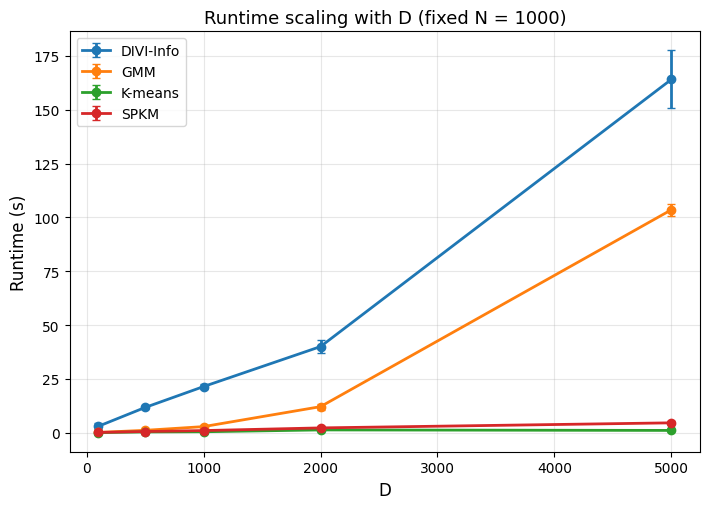

Figure 3 使用資料：


,dataset_variant,method_plot,runtime_value,runtime_mean,runtime_sd
0,synthetic_n200_d1000_noise3.0,DIVI-Info,200,4.96,0.39
2,synthetic_n500_d1000_noise3.0,DIVI-Info,500,10.54,0.29
4,synthetic_n1000_d1000_noise3.0,DIVI-Info,1000,20.20,0.57
5,synthetic_n2000_d1000_noise3.0,DIVI-Info,2000,41.51,2.07
6,synthetic_n5000_d1000_noise3.0,DIVI-Info,5000,173.60,9.29
7,synthetic_n200_d1000_noise3.0,GMM,200,1.71,0.56
9,synthetic_n500_d1000_noise3.0,GMM,500,1.93,0.15
11,synthetic_n1000_d1000_noise3.0,GMM,1000,2.86,0.55
12,synthetic_n2000_d1000_noise3.0,GMM,2000,4.57,0.69
13,synthetic_n5000_d1000_noise3.0,GMM,5000,23.36,0.80


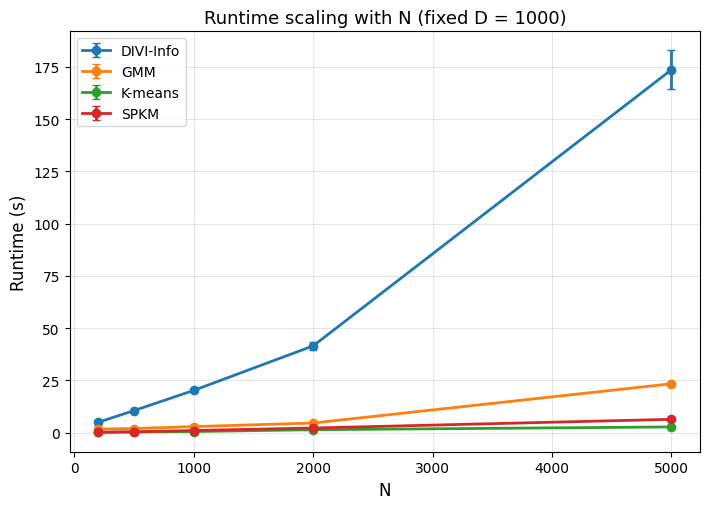

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. 讀檔
# =========================
df_d = pd.read_csv("table_runtime_dscale.csv")
df_n = pd.read_csv("table_runtime_nscale.csv")

# =========================
# 2. 工具函數
# =========================
def parse_mean_sd(x):
    """
    將 '2.96 (1.44)' 解析成 (2.96, 1.44)
    若只有單一數值，則 sd 設為 0
    """
    x = str(x).strip()
    m = re.match(r"^\s*([\-0-9.eE]+)\s*\(([\-0-9.eE]+)\)\s*$", x)
    if m:
        return float(m.group(1)), float(m.group(2))
    try:
        return float(x), 0.0
    except:
        return np.nan, np.nan

def extract_n_from_variant(s):
    m = re.search(r"_n(\d+)_", str(s))
    return int(m.group(1)) if m else np.nan

def extract_d_from_variant(s):
    m = re.search(r"_d(\d+)_", str(s))
    return int(m.group(1)) if m else np.nan

def clean_method_label(x):
    x = str(x).strip()
    mapping = {
        "KMeans": "K-means",
        "Kmeans": "K-means",
        "K-Means": "K-means",
        "DIVI-Info": "DIVI-Info",
        "GMM": "GMM",
        "SPKM": "SPKM",
    }
    return mapping.get(x, x)

def prepare_runtime_df(df):
    out = df.copy()
    out["N_fixed"] = out["dataset_variant"].apply(extract_n_from_variant)
    out["D_fixed"] = out["dataset_variant"].apply(extract_d_from_variant)
    out["method_plot"] = out["method_label"].apply(clean_method_label)

    parsed = out["Runtime (s)"].apply(parse_mean_sd)
    out["runtime_mean"] = parsed.apply(lambda z: z[0])
    out["runtime_sd"] = parsed.apply(lambda z: z[1])

    return out

def plot_runtime_scaling(
    df,
    x_col,
    x_label,
    title,
    outfile_pdf,
    outfile_png,
    method_order=("DIVI-Info", "GMM", "K-means", "SPKM")
):
    plt.figure(figsize=(7.2, 5.2))

    for method in method_order:
        sub = df[df["method_plot"] == method].copy()
        if sub.empty:
            continue
        sub = sub.sort_values(x_col)

        plt.errorbar(
            sub[x_col],
            sub["runtime_mean"],
            yerr=sub["runtime_sd"],
            marker="o",
            linewidth=2,
            capsize=3,
            label=method
        )

    plt.xlabel(x_label, fontsize=12)
    plt.ylabel("Runtime (s)", fontsize=12)
    plt.title(title, fontsize=13)
    plt.legend(frameon=True)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.savefig(outfile_pdf, bbox_inches="tight")
    plt.savefig(outfile_png, dpi=300, bbox_inches="tight")
    plt.show()

# =========================
# 3. 整理資料
# =========================
df_d2 = prepare_runtime_df(df_d)
df_n2 = prepare_runtime_df(df_n)

# =========================
# 4. Figure 2: fixed N = 1000, runtime vs D
# =========================
fixed_N = 1000
df_d_fixed = df_d2[df_d2["N_fixed"] == fixed_N].copy()

print("Figure 2 使用資料：")
display(df_d_fixed[[
    "dataset_variant", "method_plot", "runtime_value", "runtime_mean", "runtime_sd"
]].sort_values(["method_plot", "runtime_value"]))

plot_runtime_scaling(
    df=df_d_fixed,
    x_col="runtime_value",
    x_label="D",
    title=f"Runtime scaling with D (fixed N = {fixed_N})",
    outfile_pdf="runtime_dscale_fixedN1000.pdf",
    outfile_png="runtime_dscale_fixedN1000.png"
)

# =========================
# 5. Figure 3: fixed D = 1000, runtime vs N
# =========================
fixed_D = 1000
df_n_fixed = df_n2[df_n2["D_fixed"] == fixed_D].copy()

print("Figure 3 使用資料：")
display(df_n_fixed[[
    "dataset_variant", "method_plot", "runtime_value", "runtime_mean", "runtime_sd"
]].sort_values(["method_plot", "runtime_value"]))

plot_runtime_scaling(
    df=df_n_fixed,
    x_col="runtime_value",
    x_label="N",
    title=f"Runtime scaling with N (fixed D = {fixed_D})",
    outfile_pdf="runtime_nscale_fixedD1000.pdf",
    outfile_png="runtime_nscale_fixedD1000.png"
)